In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

train = pd.read_csv('../data/train.csv')
features = pd.read_csv('../data/features.csv')
stores = pd.read_csv('../data/stores.csv')

df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
df = df.merge(stores, on='Store', how='left')
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Weekly_Sales'] > 0]

Calculate annual sales per department:

In [7]:
dept_sales = df.groupby('Dept')['Weekly_Sales'].sum().reset_index()
dept_sales.columns = ['Dept', 'Annual_Sales']
dept_sales = dept_sales.sort_values('Annual_Sales', ascending=False).reset_index(drop=True)

total_sales = dept_sales['Annual_Sales'].sum()
dept_sales['Sales_%'] = (dept_sales['Annual_Sales'] / total_sales) * 100
dept_sales['Cumulative_%'] = dept_sales['Sales_%'].cumsum()

dept_sales['Annual_Sales_M'] = dept_sales['Annual_Sales'] / 1e6
dept_sales['Annual_Sales_M'] = dept_sales['Annual_Sales_M'].round(2)

ABC categories:

In [8]:
def assign_abc(cumulative_pct):
    if cumulative_pct <= 70:
        return 'A'
    elif cumulative_pct <= 90:
        return 'B'
    else:
        return 'C'

dept_sales['ABC_Category'] = dept_sales['Cumulative_%'].apply(assign_abc)

summary = dept_sales.groupby('ABC_Category').agg(
    Departments=('Dept', 'count'),
    Total_Sales_M=('Annual_Sales_M', 'sum'),
    Sales_Share=('Sales_%', 'sum')
).reset_index()

summary['Total_Sales_M'] = summary['Total_Sales_M'].round(2)
summary['Sales_Share'] = summary['Sales_Share'].round(2)

print(summary.to_string(index=False))
dept_sales[['Dept', 'Annual_Sales_M', 'Sales_%', 'Cumulative_%', 'ABC_Category']].head(20)

ABC_Category  Departments  Total_Sales_M  Sales_Share
           A           21        4686.81        69.56
           B           17        1338.55        19.87
           C           43         711.95        10.57


,Dept,Annual_Sales_M,Sales_%,Cumulative_%,ABC_Category
0,92,483.94,7.183038,7.183038,A
1,95,449.32,6.669136,13.852174,A
2,38,393.12,5.834945,19.687118,A
3,72,305.73,4.537840,24.224958,A
4,90,291.07,4.320249,28.545207,A
5,40,288.94,4.288598,32.833806,A
6,2,280.61,4.165035,36.998840,A
7,91,216.78,3.217631,40.216471,A
8,13,197.32,2.928790,43.145261,A
9,8,194.28,2.883656,46.028918,A


 Visualisation

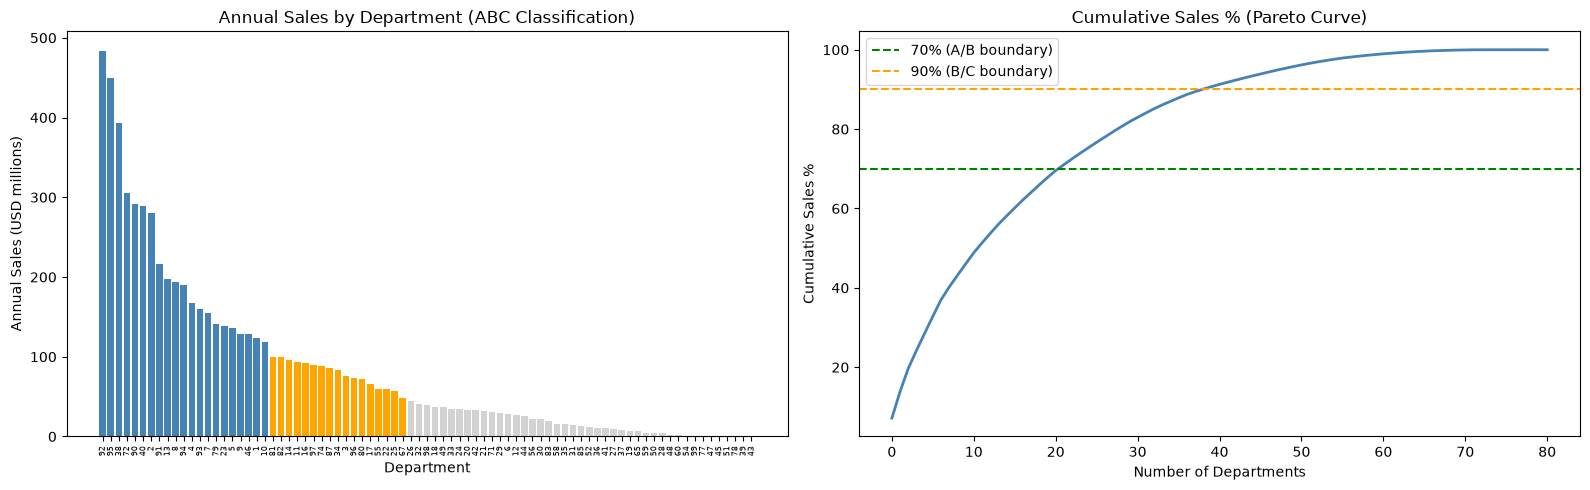

In [5]:
os.makedirs('../outputs', exist_ok=True)

colors = dept_sales['ABC_Category'].map({'A': 'steelblue', 'B': 'orange', 'C': 'lightgray'})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.bar(dept_sales['Dept'].astype(str), dept_sales['Annual_Sales'] / 1e6, color=colors)
ax1.set_title('Annual Sales by Department (ABC Classification)')
ax1.set_xlabel('Department')
ax1.set_ylabel('Annual Sales (USD millions)')
ax1.tick_params(axis='x', rotation=90, labelsize=6)

ax2.plot(range(len(dept_sales)), dept_sales['Cumulative_%'], color='steelblue', linewidth=2)
ax2.axhline(y=70, color='green', linestyle='--', label='70% (A/B boundary)')
ax2.axhline(y=90, color='orange', linestyle='--', label='90% (B/C boundary)')
ax2.set_title('Cumulative Sales % (Pareto Curve)')
ax2.set_xlabel('Number of Departments')
ax2.set_ylabel('Cumulative Sales %')
ax2.legend()

plt.tight_layout()
plt.savefig('../outputs/abc_analysis.png')
plt.show()

In [6]:
dept_sales.to_csv('../outputs/abc_classification.csv', index=False)
print("Saved abc_classification.csv")

Saved abc_classification.csv
